Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import shap
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
!pip install xgboost
!pip install shap

d:\anacoda\envs\py310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load Dataset

In [2]:
df = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")


 Initial Data Exploration

In [3]:
df.shape

(253680, 22)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [5]:
df.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [6]:
df.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.139333,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.346294,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


Binary Feature Distribution Visualization

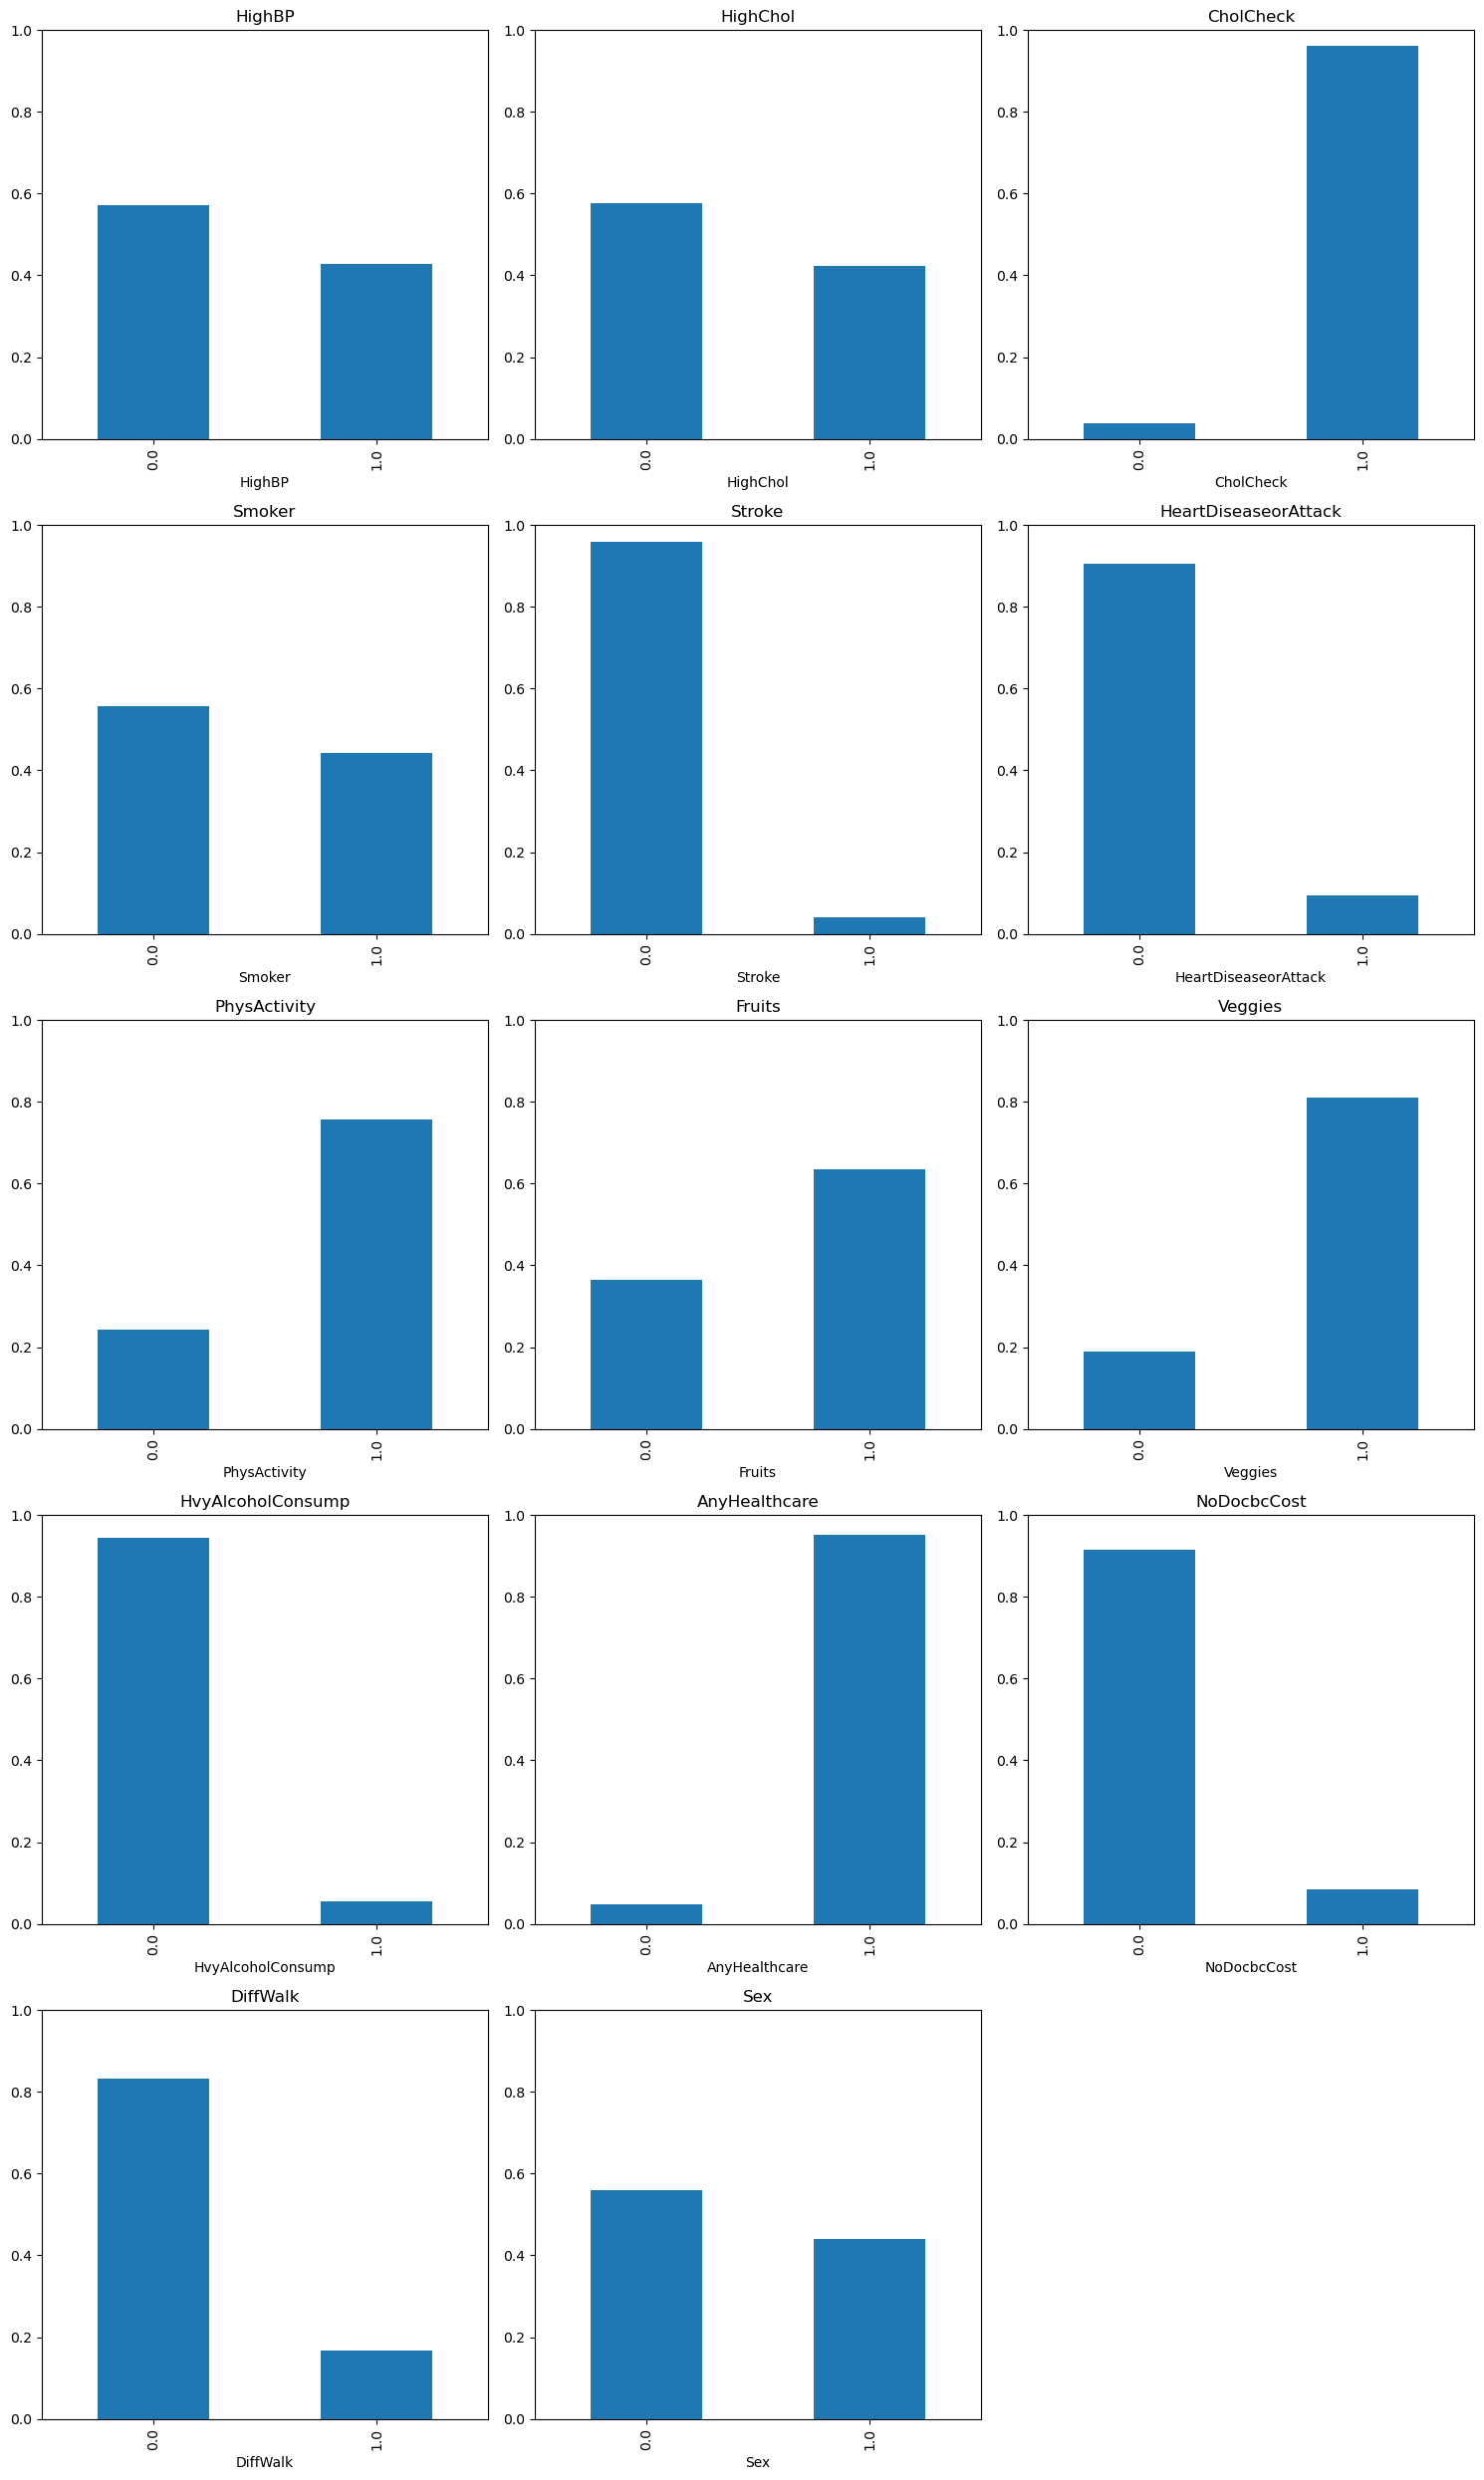

In [7]:
binary_vars = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke',
    'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
    'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost',
    'DiffWalk', 'Sex'
]

cols = 3
rows = math.ceil(len(binary_vars) / cols)

plt.figure(figsize=(15, 5 * rows))

for i, col in enumerate(binary_vars, 1):
    plt.subplot(rows, cols, i)
    df[col].value_counts(normalize=True).sort_index().plot(kind='bar')
    plt.title(col)
    plt.ylim(0, 1)

plt.tight_layout()
plt.show()


Ordinal Variable Distribution

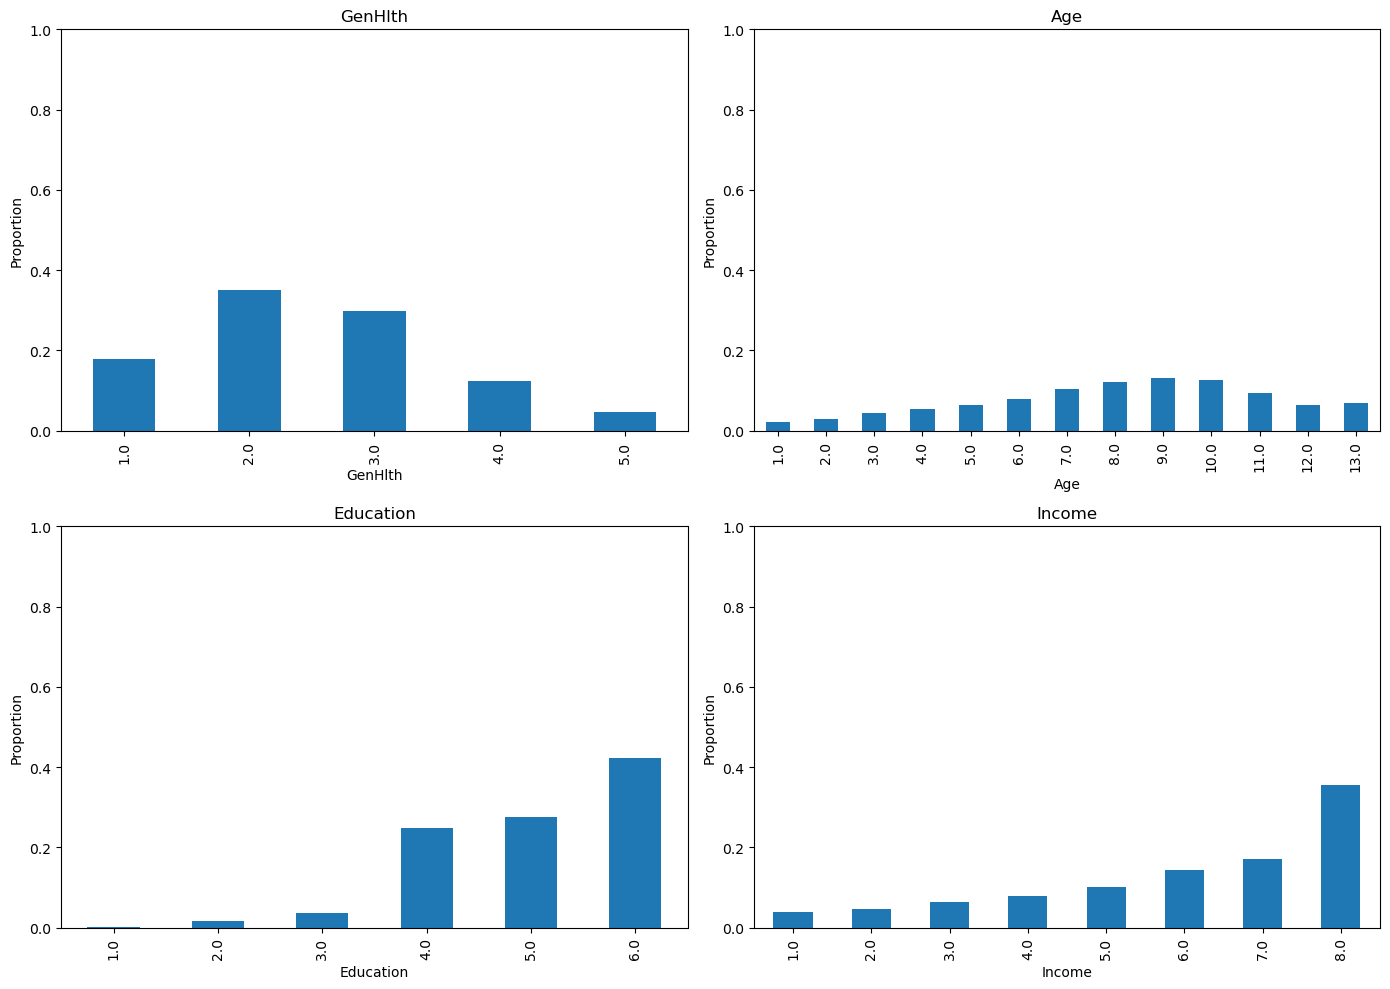

In [8]:
ordinal_vars = ['GenHlth', 'Age', 'Education', 'Income']

cols = 2
rows = math.ceil(len(ordinal_vars) / cols)

plt.figure(figsize=(14, 5 * rows))

for i, col in enumerate(ordinal_vars, 1):
    plt.subplot(rows, cols, i)
    df[col].value_counts(normalize=True).sort_index().plot(kind='bar')
    plt.title(col)
    plt.ylabel('Proportion')
    plt.ylim(0, 1)

plt.tight_layout()
plt.show()

Continuous Variable Distribution

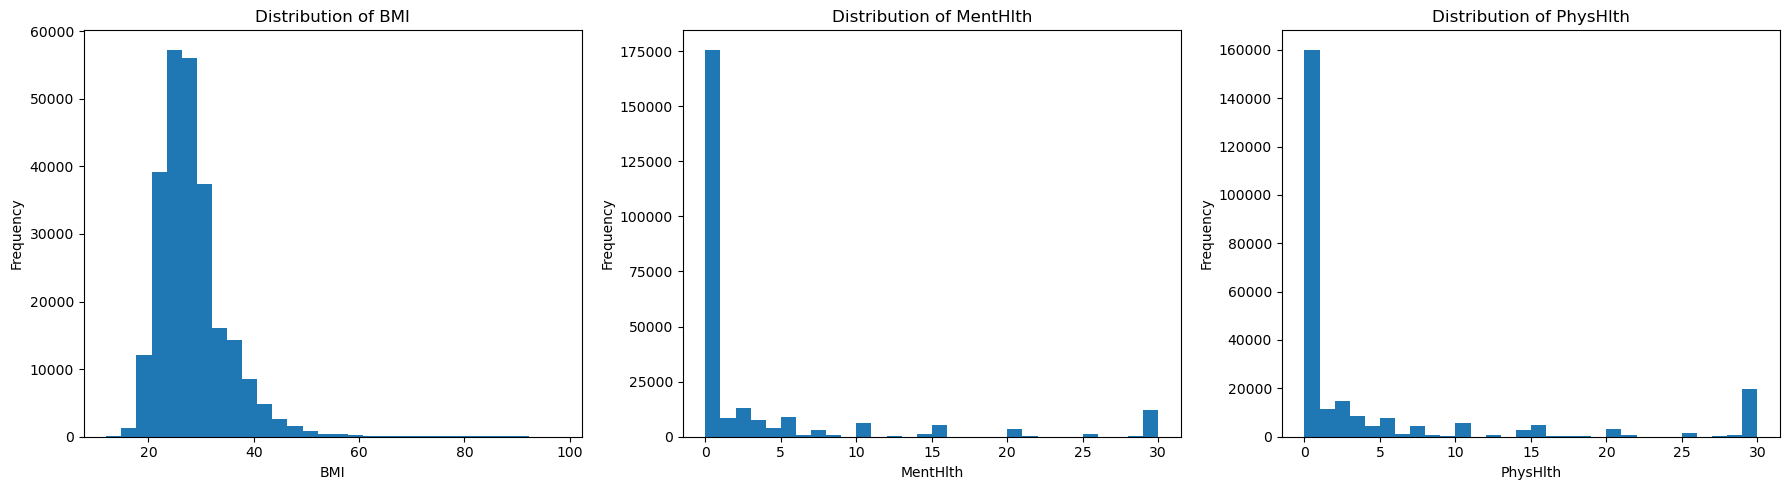

In [9]:
continuous_vars = ['BMI', 'MentHlth', 'PhysHlth']

cols = 3
rows = 1

plt.figure(figsize=(18, 5))

for i, col in enumerate(continuous_vars, 1):
    plt.subplot(rows, cols, i)
    plt.hist(df[col], bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Boxplot Analysis of Continuous Variables

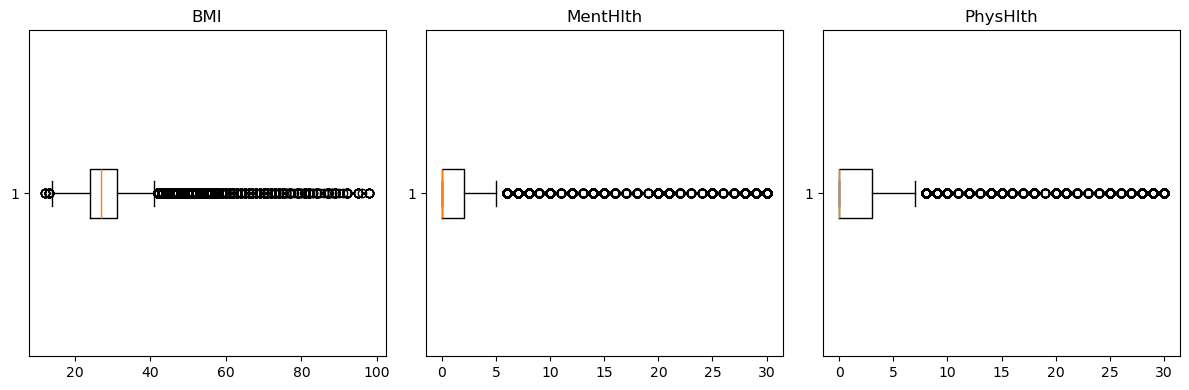

In [10]:
plt.figure(figsize=(12, 4))

for i, col in enumerate(continuous_vars, 1):
    plt.subplot(1, 3, i)
    plt.boxplot(df[col], vert=False)
    plt.title(col)

plt.tight_layout()
plt.show()

Binary Variables by Diabetes Status

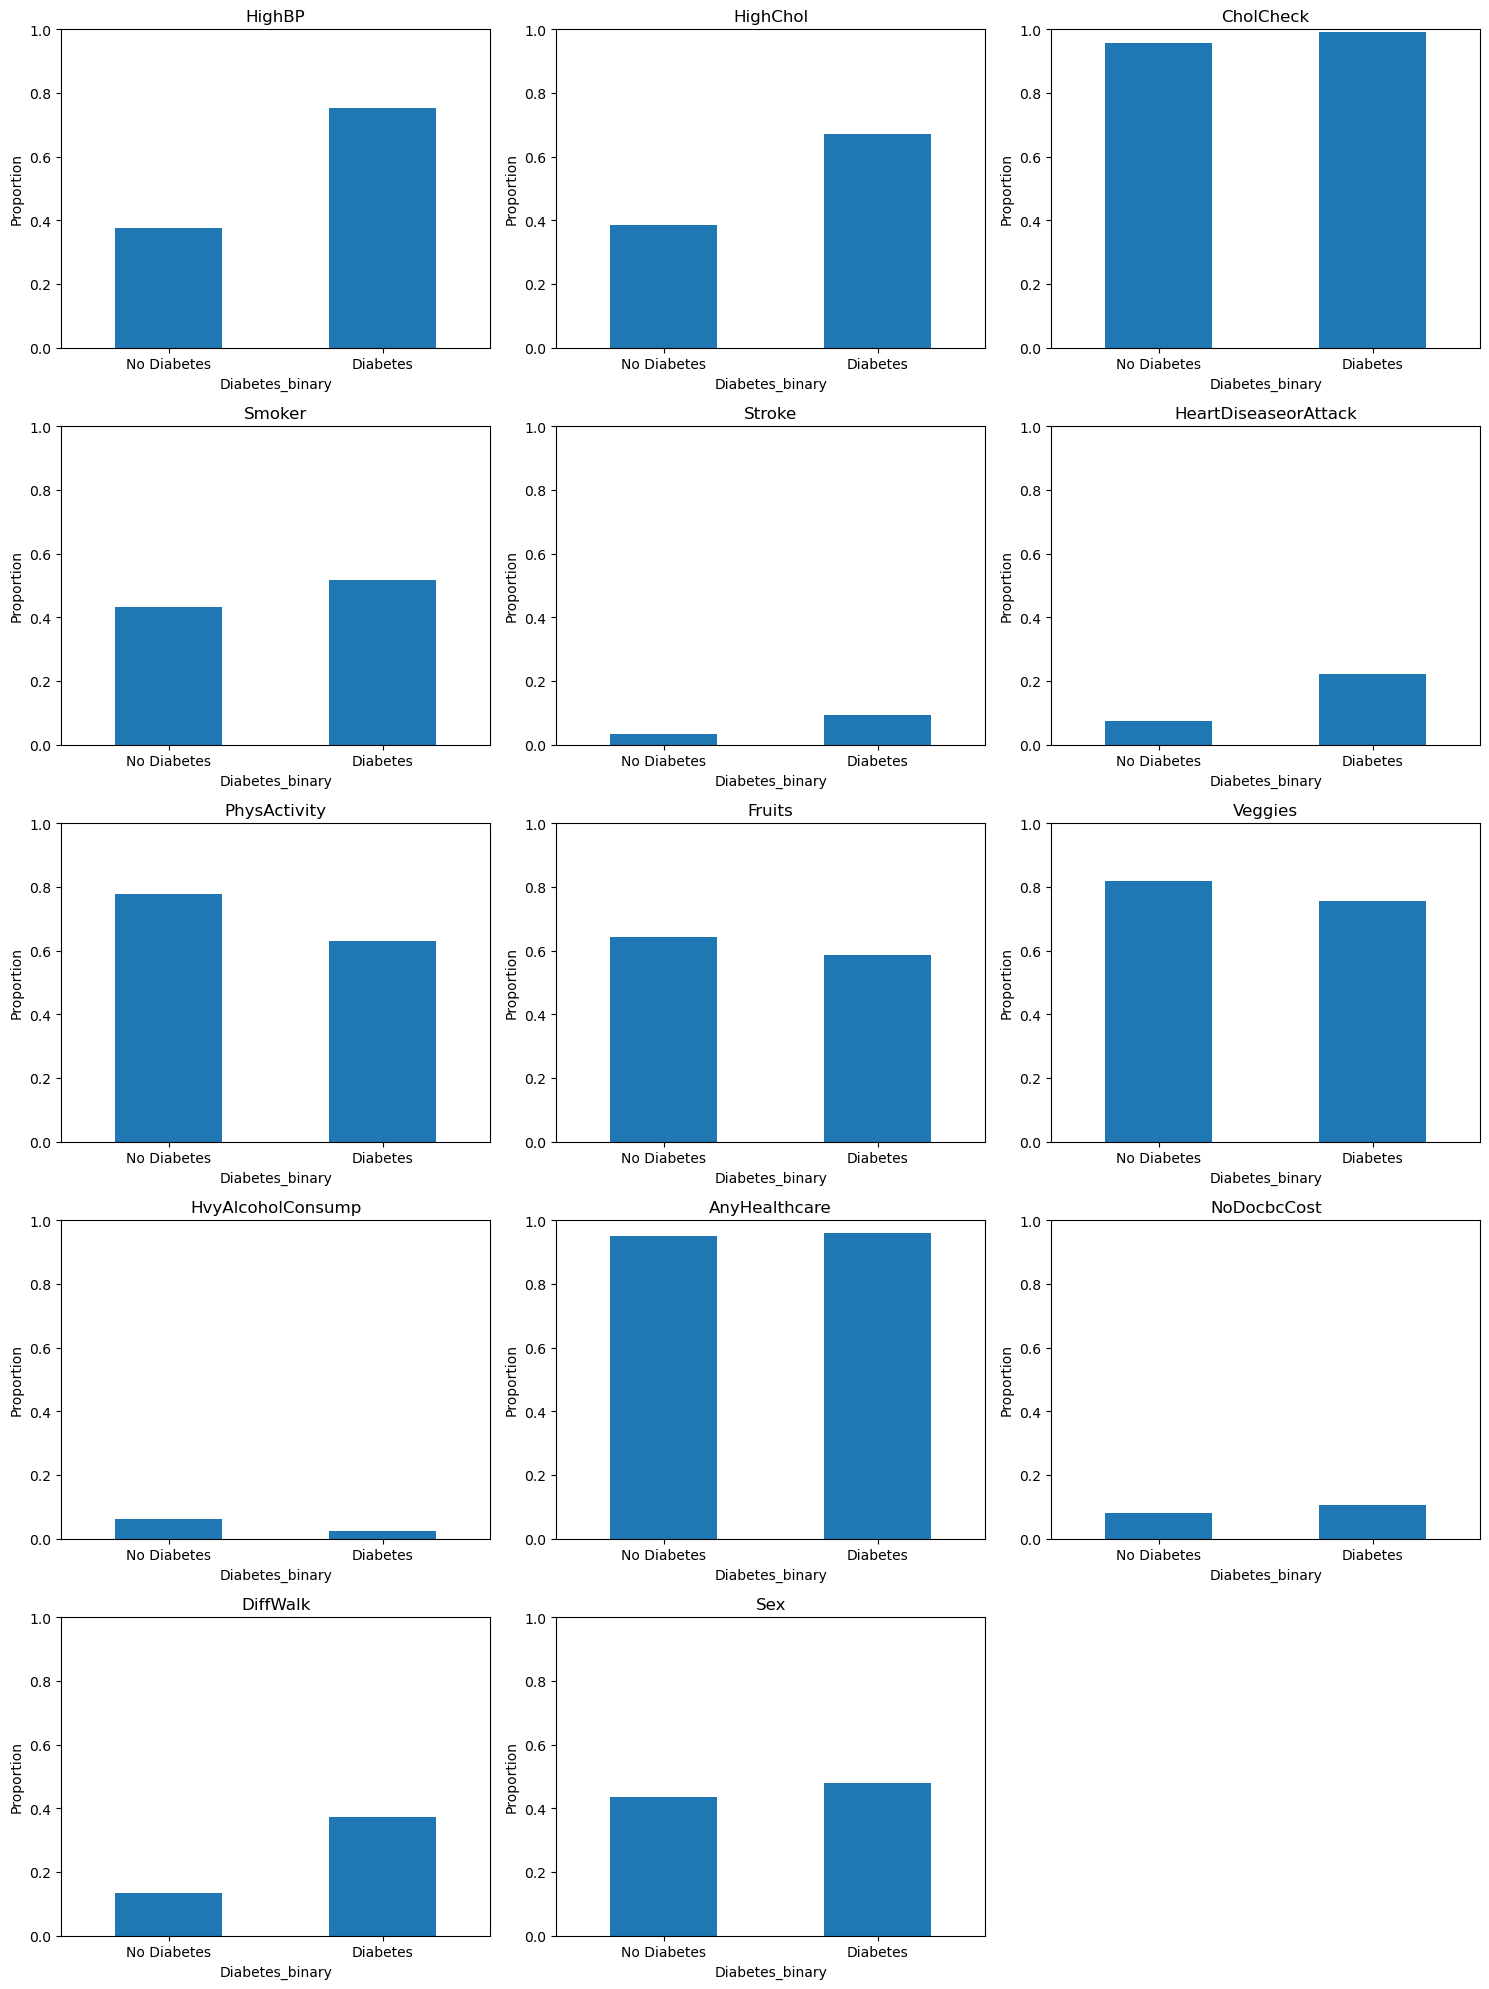

In [11]:
cols = 3
rows = math.ceil(len(binary_vars) / cols)

plt.figure(figsize=(5 * cols, 4 * rows))

for i, col in enumerate(binary_vars, 1):
    prop = (
        df.groupby('Diabetes_binary')[col]
        .mean()
        .rename({0: 'No Diabetes', 1: 'Diabetes'})
    )
    
    plt.subplot(rows, cols, i)
    prop.plot(kind='bar')
    plt.title(col)
    plt.ylabel('Proportion')
    plt.ylim(0, 1)
    plt.xticks(rotation=0)

plt.tight_layout()
plt.show()


Bivariate Analysis of Ordinal Variables and Diabetes Status

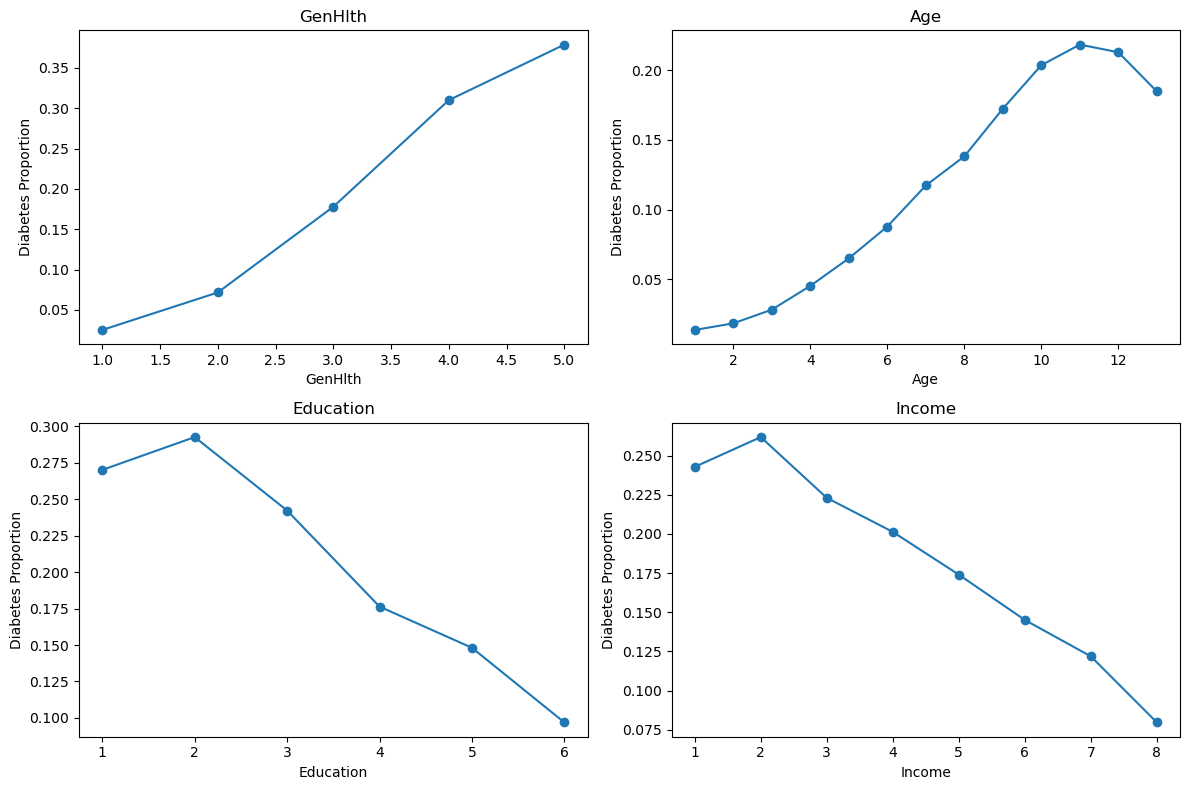

In [12]:
cols = 2
rows = math.ceil(len(ordinal_vars) / cols)

plt.figure(figsize=(6 * cols, 4 * rows))

for i, col in enumerate(ordinal_vars, 1):
    rate = df.groupby(col)['Diabetes_binary'].mean()
    
    plt.subplot(rows, cols, i)
    rate.plot(marker='o')
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel('Diabetes Proportion')

plt.tight_layout()
plt.show()



Bivariate Analysis of Continuous Variables and Diabetes Status

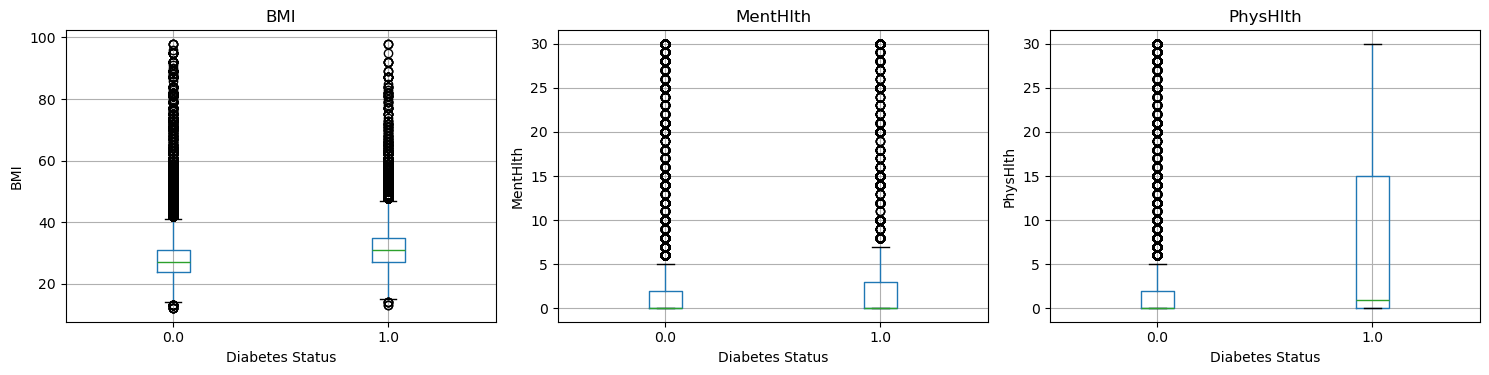

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, continuous_vars):
    df.boxplot(column=col, by='Diabetes_binary', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Diabetes Status')
    ax.set_ylabel(col)

plt.suptitle('')
plt.tight_layout()
plt.show()


#DATA Preprocessing

Checking Miising Value

In [14]:
df.isnull().sum()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Outlier Inspection for Continuous Variables

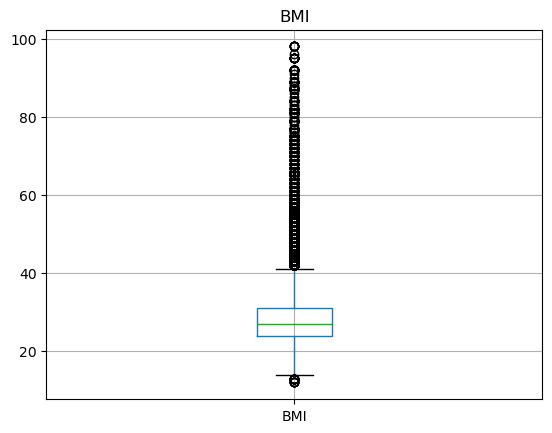

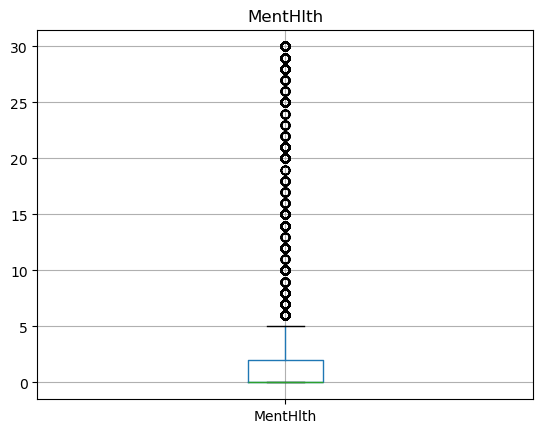

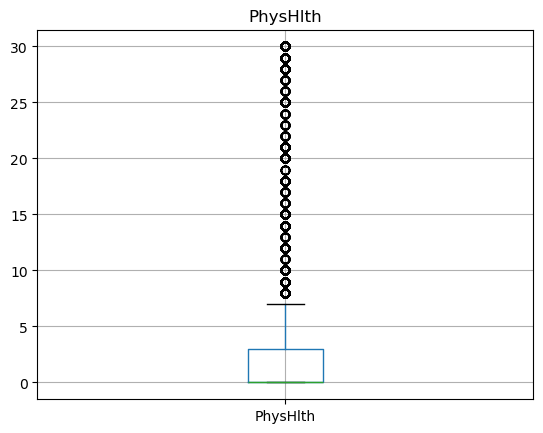

In [15]:
for col in ['BMI', 'MentHlth', 'PhysHlth']:
    df.boxplot(column=col)
    plt.title(col)
    plt.show()

Data Partitioning

In [16]:
# Separate features and target
X = df.drop(columns=['Diabetes_binary'])
y = df['Diabetes_binary']

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Verify class distribution
print("Training set class distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting set class distribution:")
print(y_test.value_counts(normalize=True))


Training set class distribution:
Diabetes_binary
0.0    0.860666
1.0    0.139334
Name: proportion, dtype: float64

Testing set class distribution:
Diabetes_binary
0.0    0.860671
1.0    0.139329
Name: proportion, dtype: float64


Feature Scaling

In [17]:
# Initialize the scaler
scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same transformation to test data
X_test_scaled = scaler.transform(X_test)

Model Building

Baseline Logistic Regression

In [18]:
# Initialize Logistic Regression (baseline)
lr = LogisticRegression(
    solver='liblinear',     # stable for binary classification
    max_iter=1000,
    random_state=42
)

# Train the model
lr.fit(X_train_scaled, y_train)

# Predict labels
y_pred = lr.predict(X_test_scaled)

# Predict probabilities (for ROC-AUC)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

# Evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

# Print results
print("Baseline Logistic Regression Performance:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Baseline Logistic Regression Performance:
Accuracy : 0.8621
Precision: 0.5164
Recall   : 0.1584
F1-score : 0.2425
ROC-AUC  : 0.8192

Confusion Matrix:
[[42618  1049]
 [ 5949  1120]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.92     43667
         1.0       0.52      0.16      0.24      7069

    accuracy                           0.86     50736
   macro avg       0.70      0.57      0.58     50736
weighted avg       0.83      0.86      0.83     50736



Random Forest Classifier

In [19]:
# Initialize Random Forest (baseline configuration)
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train model
rf.fit(X_train, y_train)

# Predictions
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Evaluation metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance:")
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-score : {f1_rf:.4f}")
print(f"ROC-AUC  : {roc_auc_rf:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))


Random Forest Performance:
Accuracy : 0.8597
Precision: 0.4903
Recall   : 0.1757
F1-score : 0.2587
ROC-AUC  : 0.7969

Confusion Matrix:
[[42376  1291]
 [ 5827  1242]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.97      0.92     43667
         1.0       0.49      0.18      0.26      7069

    accuracy                           0.86     50736
   macro avg       0.68      0.57      0.59     50736
weighted avg       0.82      0.86      0.83     50736



XGBoost Training and Evaluation

In [20]:
# Initialize XGBoost (baseline configuration)
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# Train model
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
precision_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Performance:")
print(f"Accuracy : {accuracy_xgb:.4f}")
print(f"Precision: {precision_xgb:.4f}")
print(f"Recall   : {recall_xgb:.4f}")
print(f"F1-score : {f1_xgb:.4f}")
print(f"ROC-AUC  : {roc_auc_xgb:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))


XGBoost Performance:
Accuracy : 0.8651
Precision: 0.5528
Recall   : 0.1652
F1-score : 0.2544
ROC-AUC  : 0.8270

Confusion Matrix:
[[42722   945]
 [ 5901  1168]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.93     43667
         1.0       0.55      0.17      0.25      7069

    accuracy                           0.87     50736
   macro avg       0.72      0.57      0.59     50736
weighted avg       0.83      0.87      0.83     50736



Threshold Analysis for Recall Improvement

In [21]:
# Get predicted probabilities from XGBoost (baseline)
# y_prob_xgb: probability of diabetes (class = 1)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

# sanity check
print("Predicted probability summary:")
print(pd.Series(y_prob_xgb).describe())

Predicted probability summary:
count    50736.000000
mean         0.139361
std          0.157570
min          0.000082
25%          0.018373
50%          0.075146
75%          0.212231
max          0.914299
dtype: float64


In [22]:
thresholds = [0.5, 0.4, 0.3, 0.2]

results = []

for t in thresholds:
    y_pred_t = (y_prob_xgb >= t).astype(int)
    
    results.append({
        "Threshold": t,
        "Precision": precision_score(y_test, y_pred_t),
        "Recall": recall_score(y_test, y_pred_t),
        "F1-score": f1_score(y_test, y_pred_t)
    })

threshold_df = pd.DataFrame(results)
threshold_df


,Threshold,Precision,Recall,F1-score
0,0.5,0.552769,0.165228,0.254411
1,0.4,0.486009,0.307116,0.376387
2,0.3,0.426785,0.487763,0.455242
3,0.2,0.353909,0.672372,0.463730


In [23]:
selected_threshold = 0.3

y_pred_03 = (y_prob_xgb >= selected_threshold).astype(int)

# Confusion Matrix
cm_03 = confusion_matrix(y_test, y_pred_03)

print("Confusion Matrix (Threshold = 0.3):")
print(cm_03)

print("\nClassification Report (Threshold = 0.3):")
print(classification_report(y_test, y_pred_03))


Confusion Matrix (Threshold = 0.3):
[[39036  4631]
 [ 3621  3448]]

Classification Report (Threshold = 0.3):
              precision    recall  f1-score   support

         0.0       0.92      0.89      0.90     43667
         1.0       0.43      0.49      0.46      7069

    accuracy                           0.84     50736
   macro avg       0.67      0.69      0.68     50736
weighted avg       0.85      0.84      0.84     50736



Handling Class Imbalance Using Weighted XGBoost

Class Distribution Analysis

In [24]:
y_train.value_counts(normalize=True)

Diabetes_binary
0.0    0.860666
1.0    0.139334
Name: proportion, dtype: float64

Computation of scale_pos_weight

In [25]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos
scale_pos_weight


np.float64(6.176998974431517)

Training Weighted XGBoost Model

In [26]:
xgb_weighted = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,  
    random_state=42,
    n_jobs=-1
)

xgb_weighted.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [27]:
y_pred_w = xgb_weighted.predict(X_test)
y_prob_w = xgb_weighted.predict_proba(X_test)[:, 1]

print("XGBoost with Imbalance Handling (scale_pos_weight)")

print("Accuracy :", accuracy_score(y_test, y_pred_w))
print("Precision:", precision_score(y_test, y_pred_w))
print("Recall   :", recall_score(y_test, y_pred_w))
print("F1-score :", f1_score(y_test, y_pred_w))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_w))

XGBoost with Imbalance Handling (scale_pos_weight)
Accuracy : 0.722839798170924
Precision: 0.30730228713144114
Recall   : 0.7887961522138917
F1-score : 0.44229396367097645
ROC-AUC  : 0.8263704815748211


In [28]:
print("Confusion Matrix (Weighted XGBoost):")
print(confusion_matrix(y_test, y_pred_w))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_w))

Confusion Matrix (Weighted XGBoost):
[[31098 12569]
 [ 1493  5576]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.95      0.71      0.82     43667
         1.0       0.31      0.79      0.44      7069

    accuracy                           0.72     50736
   macro avg       0.63      0.75      0.63     50736
weighted avg       0.86      0.72      0.76     50736



Model Interpretability Using SHAP

Define prediction function

In [29]:
def predict_fn(X):
    return xgb_model.predict_proba(X)[:, 1]


Initialize SHAP Explainer

In [30]:
explainer = shap.Explainer(predict_fn, X_train)

Sample test data for SHAP computation

In [31]:
X_test_sample = X_test.sample(
    n=2000,
    random_state=42
)


Compute SHAP values

In [32]:
shap_values = explainer(X_test_sample)

PermutationExplainer explainer: 2001it [02:25, 13.74it/s]                          


Visualize global feature importance

C:\Users\NEO\AppData\Local\Temp\ipykernel_46468\3779480237.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample)


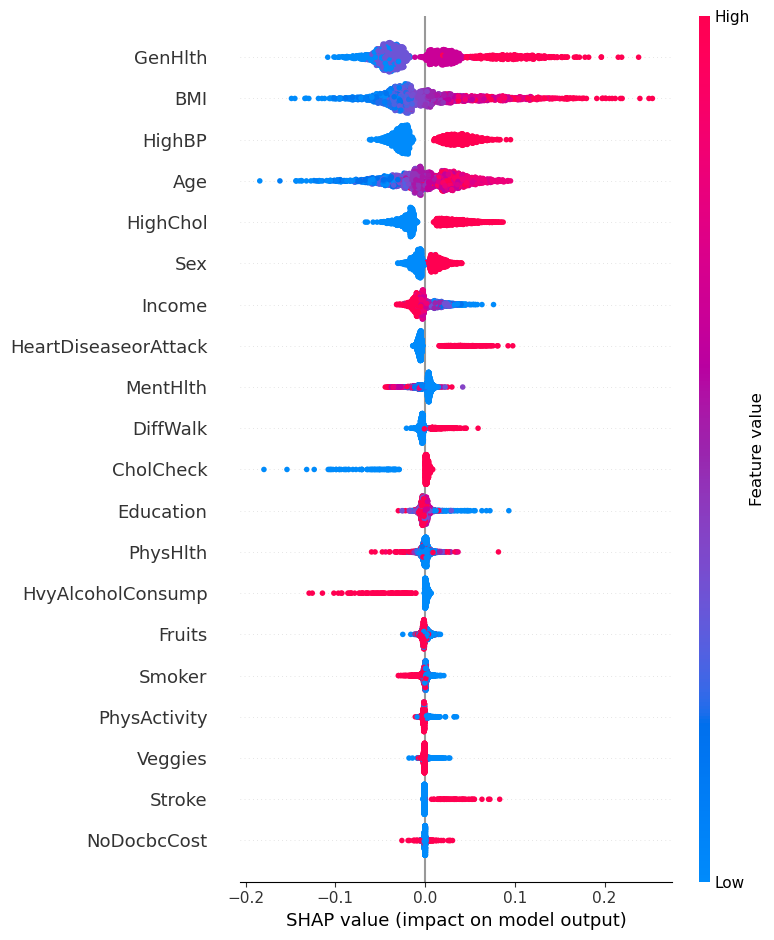

In [33]:
shap.summary_plot(shap_values, X_test_sample)

Model Saving

In [34]:
joblib.dump(xgb_weighted, "xgb_weighted_diabetes_model.pkl")

['xgb_weighted_diabetes_model.pkl']